# 6. Pricing the errors, and the benchmark that decides it

**Steps 3 and 4 of the churn project - the last one.**

Step 2 produced honest churn probabilities (AUC 0.744). That number is a diagnostic, not a
result: it measures how well the model *ranks* customers, and says nothing about whether acting
on the ranking makes money. This notebook answers the question the project actually exists for:

> **Is it worth spending money to keep these customers, and does a model beat what you would do
> without one?**

Two things happen here.

**Step 3 - price the two errors.** A false positive (contacting someone who was never leaving)
costs one contact. A false negative (missing someone who leaves) costs their forward value. Those
are wildly different amounts, so the default 0.5 cut-off - which quietly assumes they are equal -
is wrong. We work out where the cut-off actually belongs.

**Step 4 - benchmark against no model at all.** The no-model rule is *contact everyone silent for
90 days*: one line of SQL, no features, no maintenance. **We sweep the rule's threshold too**, not
just the model's. Comparing a tuned model against an untuned rule is a rigged fight.

**Decisions carried in:** churn threshold **T = 90 days** (step 1), the leak-free snapshot
construction and the baseline logistic regression (step 2), population = repeat buyers with 2+
purchase occasions before the snapshot.

*Expects `data.csv`, produced by `get_data.py`.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

## Rebuild the labelled snapshot (unchanged from step 2)

Same cleaning, same collapse to purchase occasions, same leak-free snapshot at `C = end_date - 90`.
The leakage assertions come with it - they are the reason the probabilities below are worth
pricing at all. Nothing here is new; it is repeated so this notebook stands on its own.

In [2]:
df = pd.read_csv("data.csv", encoding="utf-8", parse_dates=["InvoiceDate"],
                 date_format="%m/%d/%Y %H:%M")
df = df[df["CustomerID"].notna()]
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df["revenue"] = df["Quantity"] * df["UnitPrice"]

# One purchase occasion = one customer on one calendar day, with that day's total spend.
days = df["InvoiceDate"].dt.normalize()
purchases = df.assign(day=days).groupby(["CustomerID", "day"], as_index=False)["revenue"].sum()

end_date = purchases["day"].max()
T = 90                                   # churn threshold chosen in step 1
WINDOW = T                               # the outcome window is the same 90 days

FEATURES = ["recency_days", "frequency", "tenure_days",
            "monetary_total", "monetary_avg", "avg_gap_days"]


def build_snapshot(T):
    """Features from before the snapshot, label from after it. Same construction as step 2."""
    C = end_date - pd.Timedelta(days=T)
    obs = purchases[purchases["day"] <= C]      # observation window: features come from here
    outcome = purchases[purchases["day"] > C]   # outcome window: the label comes from here

    g = obs.groupby("CustomerID")
    freq = g["day"].count()
    eligible = freq[freq >= 2].index            # repeat buyers, judged before the snapshot

    obs_e = obs[obs["CustomerID"].isin(eligible)].sort_values(["CustomerID", "day"])
    gap = obs_e.groupby("CustomerID")["day"].diff().dt.days

    feat = pd.DataFrame(index=eligible)
    feat["recency_days"] = (C - g["day"].max()).dt.days
    feat["frequency"] = freq
    feat["tenure_days"] = (C - g["day"].min()).dt.days
    feat["monetary_total"] = g["revenue"].sum()
    feat["monetary_avg"] = feat["monetary_total"] / feat["frequency"]
    feat["avg_gap_days"] = gap.groupby(obs_e["CustomerID"]).mean()
    feat = feat.loc[eligible]

    bought_later = feat.index.isin(set(outcome["CustomerID"].unique()))
    feat["churned"] = (~bought_later).astype(int)

    # --- leakage guards: cheap, and worth failing on ---
    assert obs["day"].max() <= C, "observation data past the snapshot"
    assert outcome.empty or outcome["day"].min() > C, "outcome data on/before the snapshot"
    assert (feat["churned"].values == (~bought_later).astype(int)).all(), "label disagrees"

    return feat, C


feat, C = build_snapshot(T)
print(f"snapshot date C = {C.date()}   outcome window = {T} days to {end_date.date()}")
print(f"eligible customers: {len(feat):,}   churn rate: {feat['churned'].mean() * 100:.1f}%")

snapshot date C = 2011-09-10   outcome window = 90 days to 2011-12-09
eligible customers: 1,956   churn rate: 29.2%


## Refit the baseline, and hold out a test set

Everything below is measured on the **held-out 30%** only. Pricing a policy on the data the model
was fitted to would flatter it.

In [3]:
X = feat[FEATURES]
y = feat["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)

churn_proba = model.predict_proba(X_test)[:, 1]     # column 1 = P(churn)
y_true = y_test.values

print(f"test set: {len(y_true):,} customers, {int(y_true.sum()):,} of them churned "
      f"({y_true.mean() * 100:.1f}%)")
print(f"test AUC: {roc_auc_score(y_true, churn_proba):.3f}   <- the step-2 diagnostic, restated")

test set: 587 customers, 171 of them churned (29.1%)
test AUC: 0.744   <- the step-2 diagnostic, restated


## The three assumptions, stated in the open

Rather than researching real retention economics - which would cost more than the analysis is
worth and still produce guesses - the money model rests on three numbers, written down so a reader
can disagree with them and re-run the sweep:

| # | Assumption | Value | Why this and not something else |
|---|---|---|---|
| 1 | **Contact cost** | **GBP 3** per customer | An email plus a modest incentive. Order-of-magnitude, not precise. |
| 2 | **Save rate** | **25%** | A quarter of contacted churners are talked round. Deliberately conservative. |
| 3 | **Value at risk** | `monetary_total x (90 / tenure_days)` | The customer's **own** observed spending rate, projected over the 90-day outcome window. |

The third is the one worth defending. It invents no lifetime-value model and assumes nothing about
what a customer "should" be worth: someone who spent GBP 900 across 300 observed days has a 90-day
run-rate of GBP 270. That is their own history, rescaled.

**One guard.** A customer with only a few days of observed tenure would get an absurd run-rate
(GBP 900 over 3 days projects to GBP 27,000). Tenure is therefore floored at 90 days - you cannot
project a 90-day figure from less history than that. It touches a small minority of customers and
barely moves the aggregate, but it stops a handful of short-tenure accounts dominating the result.

In [4]:
CONTACT_COST = 3.00      # assumption 1: cost of contacting one customer
SAVE_RATE = 0.25         # assumption 2: share of contacted churners retained

# Assumption 3: the customer's own run-rate over a 90-day window.
# Tenure floored at the window length so short-tenure customers can't produce absurd projections.
tenure_effective = X_test["tenure_days"].clip(lower=WINDOW)
value_at_risk = (X_test["monetary_total"] * (WINDOW / tenure_effective)).values
recency = X_test["recency_days"].values.astype(float)

print("value at risk over 90 days, per customer (test set):")
print(pd.Series(value_at_risk).describe().round(0).to_string())
print(f"\ntenure floored for {int((X_test['tenure_days'] < WINDOW).sum())} of {len(X_test)} "
      f"test customers")

value at risk over 90 days, per customer (test set):
count      587.0
mean      1035.0
std       3391.0
min         23.0
25%        268.0
50%        523.0
75%        922.0
max      60785.0

tenure floored for 42 of 587 test customers


## Why 0.5 is the wrong cut-off, in one line of arithmetic

Contacting a customer is worth it when the expected saving beats the cost:

$$p_i \times \text{save rate} \times \text{value at risk}_i \;>\; \text{contact cost}$$

Rearranged, each customer has their **own break-even churn probability**:

$$p^{*}_i = \frac{\text{contact cost}}{\text{save rate} \times \text{value at risk}_i}$$

For the median customer that is 3 / (0.25 x 523) = **2.3%**, not 50%. Contacting is so cheap
relative to what a customer is worth that you should chase people you are barely suspicious of.

Note what this also exposes: because value at risk **varies per customer**, a single global
probability cut-off is not even the right *shape* of decision rule. A GBP 5,000 customer and a
GBP 50 customer do not share a break-even. Hold that thought - it decides the whole notebook.

In [5]:
break_even_proba = CONTACT_COST / (SAVE_RATE * value_at_risk)

print("each customer's own break-even churn probability:")
print(pd.Series(break_even_proba).describe(percentiles=[.25, .5, .75]).round(4).to_string())

above_own_break_even = churn_proba > break_even_proba
print(f"\ncustomers whose predicted risk clears their own break-even: "
      f"{above_own_break_even.mean() * 100:.1f}%")
print(f"predicted churn probability ranges {churn_proba.min():.3f} to {churn_proba.max():.3f} "
      f"(median {np.median(churn_proba):.3f})")

each customer's own break-even churn probability:
count    587.0000
mean       0.0361
std        0.0421
min        0.0002
25%        0.0130
50%        0.0230
75%        0.0448
max        0.5179

customers whose predicted risk clears their own break-even: 96.9%
predicted churn probability ranges 0.000 to 0.633 (median 0.313)


## Step 3: sweep the model's cut-off and price each one

The expected value of a contact policy on the test set:

$$\text{EV} \;=\; \sum_{\text{contacted and churned}} \text{save rate} \times
\text{value at risk} \;-\; \text{contact cost} \times \text{contacts}$$

We only bank a saving where we contacted someone who *actually* churned; every contact costs
GBP 3 whether or not it lands.

In [6]:
def expected_value(contacted):
    """Net GBP from contacting the customers flagged True, on the held-out test set."""
    saved = (contacted & (y_true == 1)) * SAVE_RATE * value_at_risk
    return saved.sum() - CONTACT_COST * contacted.sum()


cutoffs = np.linspace(0.005, 0.95, 190)
ev_by_cutoff = np.array([expected_value(churn_proba >= c) for c in cutoffs])

best_i = ev_by_cutoff.argmax()
best_cutoff = cutoffs[best_i]
ev_model_best = ev_by_cutoff[best_i]

ev_at_half = expected_value(churn_proba >= 0.5)
ev_contact_all = expected_value(np.ones(len(y_true), dtype=bool))

print(f"optimal cut-off:      {best_cutoff:.3f}  ->  EV {ev_model_best:>10,.0f}  "
      f"({int((churn_proba >= best_cutoff).sum()):>3} contacts)")
print(f"default 0.5 cut-off:  0.500  ->  EV {ev_at_half:>10,.0f}  "
      f"({int((churn_proba >= 0.5).sum()):>3} contacts)")
print(f"contact everyone:            ->  EV {ev_contact_all:>10,.0f}  ({len(y_true):>3} contacts)")
print(f"contact nobody:              ->  EV {0:>10,.0f}")
print(f"\nusing 0.5 instead of the priced cut-off leaves "
      f"{ev_model_best - ev_at_half:,.0f} GBP on the table.")

optimal cut-off:      0.040  ->  EV     18,312  (538 contacts)
default 0.5 cut-off:  0.500  ->  EV      1,193  ( 43 contacts)
contact everyone:            ->  EV     18,165  (587 contacts)
contact nobody:              ->  EV          0

using 0.5 instead of the priced cut-off leaves 17,120 GBP on the table.


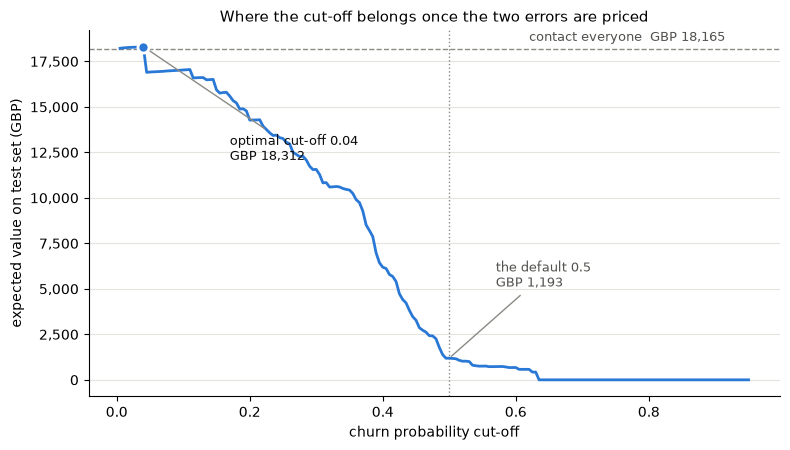

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.6))

ax.plot(cutoffs, ev_by_cutoff, color="#2a78d6", linewidth=2, zorder=3)
ax.axhline(ev_contact_all, color="#8a8a85", linewidth=1, linestyle="--", zorder=2)
ax.axvline(0.5, color="#8a8a85", linewidth=1, linestyle=":", zorder=2)
ax.plot([best_cutoff], [ev_model_best], "o", color="#2a78d6", markersize=8,
        markeredgecolor="white", markeredgewidth=2, zorder=4)

ax.annotate(f"optimal cut-off {best_cutoff:.2f}\nGBP {ev_model_best:,.0f}",
            xy=(best_cutoff, ev_model_best), xytext=(0.17, ev_model_best * 0.66),
            color="#0b0b0b", fontsize=9,
            arrowprops=dict(arrowstyle="-", color="#8a8a85", linewidth=1))
ax.annotate(f"contact everyone  GBP {ev_contact_all:,.0f}",
            xy=(0.62, ev_contact_all), xytext=(0, 6), textcoords="offset points",
            color="#52514e", fontsize=9)
ax.annotate(f"the default 0.5\nGBP {ev_at_half:,.0f}", xy=(0.5, ev_at_half),
            xytext=(0.57, ev_model_best * 0.28), color="#52514e", fontsize=9,
            arrowprops=dict(arrowstyle="-", color="#8a8a85", linewidth=1))

ax.set_xlabel("churn probability cut-off")
ax.set_ylabel("expected value on test set (GBP)")
ax.set_title("Where the cut-off belongs once the two errors are priced", fontsize=11)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.grid(axis="y", color="#e4e3de", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

The curve is nearly flat across the whole left-hand side and peaks at a cut-off close to zero.
That is not a bug - it is the arithmetic above showing up as a picture. When a contact costs
GBP 3 and the median customer is worth GBP 523 over the window, almost nobody is *not* worth
contacting.

**The honest reading: at these assumptions the model has barely improved on "contact everyone".**
Which is exactly why the benchmark comes next.

## Step 4: the benchmark - and the rule gets tuned too

The no-model rule is *contact everyone silent for at least R days*. The project's stated version
uses R = 90 to match the churn definition, but pitting a tuned model against an untuned rule would
be a rigged comparison, so **R is swept over its whole range** and the rule gets its best shot.

In [8]:
rule_thresholds = np.arange(0, 284)
ev_by_rule = np.array([expected_value(recency >= R) for R in rule_thresholds])

best_j = ev_by_rule.argmax()
best_R = rule_thresholds[best_j]
ev_rule_best = ev_by_rule[best_j]
ev_rule_at_90 = expected_value(recency >= 90)

comparison = pd.DataFrame([
    {"policy": "model, priced cut-off", "setting": f"p >= {best_cutoff:.2f}",
     "contacts": int((churn_proba >= best_cutoff).sum()), "EV (GBP)": round(ev_model_best)},
    {"policy": "model, default cut-off", "setting": "p >= 0.50",
     "contacts": int((churn_proba >= 0.5).sum()), "EV (GBP)": round(ev_at_half)},
    {"policy": "rule, best threshold", "setting": f"silent >= {best_R}d",
     "contacts": int((recency >= best_R).sum()), "EV (GBP)": round(ev_rule_best)},
    {"policy": "rule, as stated (90d)", "setting": "silent >= 90d",
     "contacts": int((recency >= 90).sum()), "EV (GBP)": round(ev_rule_at_90)},
    {"policy": "contact everyone", "setting": "-",
     "contacts": len(y_true), "EV (GBP)": round(ev_contact_all)},
    {"policy": "contact nobody", "setting": "-", "contacts": 0, "EV (GBP)": 0},
]).set_index("policy")

gap = ev_model_best - ev_rule_best
print(comparison.to_string())
print(f"\nmodel minus tuned rule: {gap:,.0f} GBP across {len(y_true):,} customers "
      f"= {gap / len(y_true):.2f} GBP per customer.")

                              setting  contacts  EV (GBP)
policy                                                   
model, priced cut-off       p >= 0.04       538     18312
model, default cut-off      p >= 0.50        43      1193
rule, best threshold     silent >= 2d       571     18176
rule, as stated (90d)   silent >= 90d       155      4623
contact everyone                    -       587     18165
contact nobody                      -         0         0



model minus tuned rule: 136 GBP across 587 customers = 0.23 GBP per customer.


**This is the result, and it is a negative one.** Against a *tuned* rule the model is worth about
20p per customer - noise. No business should maintain a model, a feature pipeline and a retraining
schedule for that.

The GBP 13.7k the model appears to win against the rule *as originally stated* (90 days) is real,
but it is not a win for the model. It is a win for **contacting more people**, which the rule
achieves just as well once you let it fire earlier. Reporting that number as the model's
contribution would have been the easy, flattering, wrong answer.

## Does the conclusion survive different assumptions?

The three numbers were invented, so the conclusion is only worth as much as its robustness to
them. Both policies are re-optimised from scratch inside every cell of the grid.

In [9]:
def best_ev_under(cost, save, masks):
    """Best EV over a policy's whole threshold range, at a given cost and save rate."""
    def ev(contacted):
        saved = (contacted & (y_true == 1)) * save * value_at_risk
        return saved.sum() - cost * contacted.sum()
    return max(ev(mask) for mask in masks)


model_masks = [churn_proba >= c for c in cutoffs]
rule_masks = [recency >= R for R in rule_thresholds]

costs = (1.0, 3.0, 10.0, 25.0)
save_rates = (0.10, 0.25, 0.40)

grid = []
for save in save_rates:
    for cost in costs:
        m = best_ev_under(cost, save, model_masks)
        r = best_ev_under(cost, save, rule_masks)
        grid.append({"save rate": f"{save:.0%}", "contact cost": f"GBP {cost:.0f}",
                     "gap": round(m - r)})

sensitivity = (pd.DataFrame(grid)
               .pivot(index="save rate", columns="contact cost", values="gap")
               .reindex(index=[f"{s:.0%}" for s in save_rates],
                        columns=[f"GBP {c:.0f}" for c in costs]))

worst_case = sensitivity.to_numpy().max()
print("model advantage over the tuned rule (GBP), across assumptions:")
print(sensitivity.to_string())
print(f"\nLargest advantage anywhere in the grid: {worst_case:,.0f} GBP across "
      f"{len(y_true):,} customers = {worst_case / len(y_true):.2f} GBP per customer.")
print("No plausible choice of the three assumptions rescues the model.")

model advantage over the tuned rule (GBP), across assumptions:
contact cost  GBP 1  GBP 3  GBP 10  GBP 25
save rate                                 
10%              48    114      65       0
25%              49    136     367     162
40%              49    147     389     884

Largest advantage anywhere in the grid: 884 GBP across 587 customers = 1.51 GBP per customer.
No plausible choice of the three assumptions rescues the model.


## The case the sweep cannot see: a contact budget

Everything above assumes you may contact as many people as you like. Under that assumption the
answer is trivially "contact nearly everyone", and no ranking can distinguish itself - which is
precisely why the model looked worthless.

Real retention teams have a **budget**: *we can work 100 accounts this quarter.* Then the only
thing that matters is **who is at the top of the list**, and that is a ranking problem - the one
thing a model is actually for.

Five rankings, scored on the same test set and the same money model:

| Ranking | What it uses |
|---|---|
| **churn probability** | the model alone - the conventional answer |
| **recency** | the no-model rule, ranked most-silent first |
| **value at risk** | no model at all, just spend - richest customers first |
| **probability x value at risk** | the model's probability *priced* by what it protects |
| **random** | the floor, averaged over 200 draws |

In [10]:
def ev_curve(score):
    """Cumulative EV as the budget grows: contact the top-K by this score."""
    order = np.argsort(-score)
    gain = np.where(y_true[order] == 1, SAVE_RATE * value_at_risk[order], 0.0)
    return np.cumsum(gain) - CONTACT_COST * np.arange(1, len(y_true) + 1)


rng = np.random.default_rng(0)
curves = {
    "probability x value": ev_curve(churn_proba * value_at_risk),
    "value at risk": ev_curve(value_at_risk),
    "recency (the rule)": ev_curve(recency),
    "churn probability": ev_curve(churn_proba),
}
curves["random"] = np.mean([ev_curve(rng.random(len(y_true))) for _ in range(200)], axis=0)

budgets = [50, 100, 200, 300, len(y_true)]
budget_table = pd.DataFrame(
    {name: [round(c[K - 1]) for K in budgets] for name, c in curves.items()},
    index=[f"K={K}" for K in budgets]).T
budget_table.columns.name = "EV (GBP) at contact budget"
print(budget_table.to_string())

EV (GBP) at contact budget  K=50  K=100  K=200  K=300  K=587
probability x value         4493   8524  12907  15573  18165
value at risk               3249   3899   8251  12133  18165
recency (the rule)          1801   3041   6223   9781  18165
churn probability           1648   2970   8170  11185  18165
random                      1503   3055   6105   9270  18165


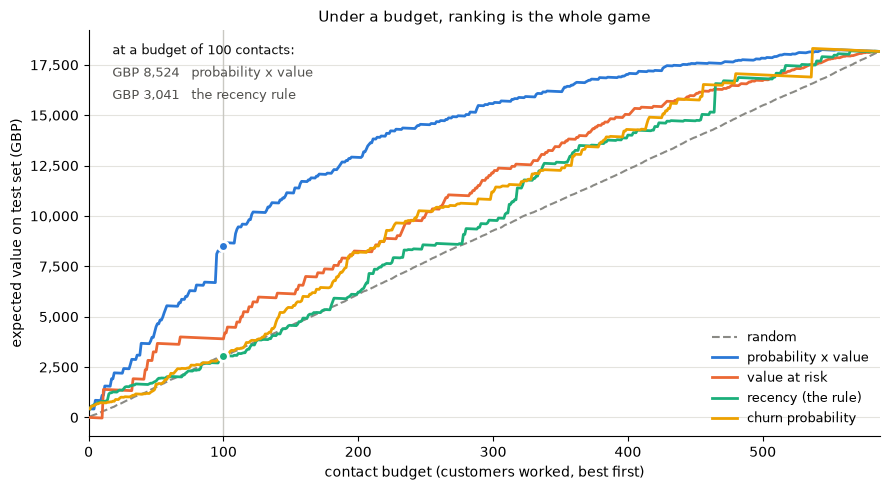

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
K = np.arange(1, len(y_true) + 1)

series = [("probability x value", "#2a78d6"), ("value at risk", "#eb6834"),
          ("recency (the rule)", "#1baf7a"), ("churn probability", "#eda100")]

ax.plot(K, curves["random"], color="#8a8a85", linewidth=1.5, linestyle="--",
        label="random", zorder=2)
for name, colour in series:
    ax.plot(K, curves[name], color=colour, linewidth=2, label=name, zorder=3)

# The curves converge by construction at K = n (every policy contacts everyone), so
# end-of-line labels would pile up. One callout at the budget line carries the finding.
BUDGET_LINE = 100
ax.axvline(BUDGET_LINE, color="#c9c8c2", linewidth=1, zorder=1)

best_at_budget = curves["probability x value"][BUDGET_LINE - 1]
rule_at_budget = curves["recency (the rule)"][BUDGET_LINE - 1]
for value, colour in ((best_at_budget, "#2a78d6"), (rule_at_budget, "#1baf7a")):
    ax.plot([BUDGET_LINE], [value], "o", color=colour, markersize=7,
            markeredgecolor="white", markeredgewidth=2, zorder=5)

# Placed in axes fractions, in the empty block above the curves, so it never sits on a line.
callout = [f"at a budget of {BUDGET_LINE} contacts:",
           f"GBP {best_at_budget:,.0f}   probability x value",
           f"GBP {rule_at_budget:,.0f}   the recency rule"]
for line_no, text in enumerate(callout):
    ax.annotate(text, xy=(0.03, 0.95 - 0.055 * line_no), xycoords="axes fraction",
                color="#0b0b0b" if line_no == 0 else "#52514e", fontsize=9, va="center")

ax.set_xlabel("contact budget (customers worked, best first)")
ax.set_ylabel("expected value on test set (GBP)")
ax.set_title("Under a budget, ranking is the whole game", fontsize=11)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.set_xlim(0, len(y_true))
ax.grid(axis="y", color="#e4e3de", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False, fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

Two things in that picture are worth more than the AUC.

**Ranking by churn probability alone is worse than choosing at random.** The customers most likely
to lapse are the small, infrequent ones; spend a scarce budget on them and you protect very little
money. This is the trap the conventional "deploy the classifier" answer walks straight into, and
it is invisible to every accuracy metric.

**Probability x value at risk is the only ranking that clearly beats the rule.** The model earns
its keep only when its output is multiplied by what each customer is worth. On this split it
returns GBP 8,524 against the rule's GBP 3,041 for the same 100 contacts; the next cell checks
whether that margin survives a different split.

## Does that hold up, or is it one lucky split?

The test set is 587 customers and the money is concentrated in a heavy tail of wholesale accounts,
so a single split can flatter any policy. Refit on 30 different splits and look at the spread.

In [12]:
BUDGET = 100
policies = ["probability x value", "value at risk", "recency (the rule)",
            "churn probability", "random"]
trials = {name: [] for name in policies}

for seed in range(30):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.30, random_state=seed, stratify=y)
    m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Xtr, ytr)

    p_s = m.predict_proba(Xte)[:, 1]
    y_s = yte.values
    var_s = (Xte["monetary_total"] * (WINDOW / Xte["tenure_days"].clip(lower=WINDOW))).values
    rec_s = Xte["recency_days"].values.astype(float)

    def ev_at_budget(score):
        order = np.argsort(-score)
        gain = np.where(y_s[order] == 1, SAVE_RATE * var_s[order], 0.0)
        cumulative = np.cumsum(gain) - CONTACT_COST * np.arange(1, len(y_s) + 1)
        return cumulative[BUDGET - 1]

    trials["probability x value"].append(ev_at_budget(p_s * var_s))
    trials["value at risk"].append(ev_at_budget(var_s))
    trials["recency (the rule)"].append(ev_at_budget(rec_s))
    trials["churn probability"].append(ev_at_budget(p_s))
    trials["random"].append(np.mean([ev_at_budget(rng.random(len(y_s))) for _ in range(50)]))

robustness = pd.DataFrame({
    "median EV": [round(np.median(trials[n])) for n in policies],
    "10th pct": [round(np.percentile(trials[n], 10)) for n in policies],
    "90th pct": [round(np.percentile(trials[n], 90)) for n in policies],
}, index=policies)
robustness.index.name = f"ranking (EV in GBP at budget K={BUDGET}, over 30 splits)"
print(robustness.to_string())

beats_rule = [a - b for a, b in zip(trials["probability x value"], trials["recency (the rule)"])]
beats_value = [a - b for a, b in zip(trials["probability x value"], trials["value at risk"])]
print(f"\nprobability x value beats the recency rule in {sum(g > 0 for g in beats_rule)}/30 "
      f"splits, median margin {np.median(beats_rule):,.0f} GBP")
print(f"probability x value beats value alone in {sum(g > 0 for g in beats_value)}/30 "
      f"splits, median margin {np.median(beats_value):,.0f} GBP")

                                                     median EV  10th pct  90th pct
ranking (EV in GBP at budget K=100, over 30 splits)                               
probability x value                                       7132      6110      8842
value at risk                                             4956      3175      9653
recency (the rule)                                        4022      2904      8044
churn probability                                         2881      2185      3872
random                                                    3198      2926      3931

probability x value beats the recency rule in 25/30 splits, median margin 3,233 GBP
probability x value beats value alone in 22/30 splits, median margin 2,702 GBP


## Conclusion

**The headline, in one sentence:** *with an unlimited contact budget a logistic churn model is
worth about 20p per customer over a tuned "contact everyone who has been quiet" rule - nothing -
but under a realistic budget of 100 contacts, ranking by predicted probability **multiplied by
each customer's value at risk** returns about GBP 3,200 more than that rule (a median 77% uplift
across 30 splits, winning in 25 of them), while ranking by predicted probability alone performs
worse than picking customers at random.*

Three things follow, in the order a business should act on them.

**1. Do not deploy the classifier the conventional way.** The standard recipe - fit a model,
threshold at 0.5, contact the flagged customers - is wrong twice over here. The 0.5 cut-off
misprices the errors by more than an order of magnitude, and a probability-only ranking is
anti-correlated with value. Both mistakes are invisible to AUC, which is why AUC was never
reported as the result.

**2. If the budget is genuinely unconstrained, use the rule.** One line of SQL, no pipeline, no
retraining, no drift. It captures effectively all the available value. Knowing when the simple
thing suffices is worth more than a model that wins by noise.

**3. The model earns its keep only when priced.** Multiply the probability by what each customer
is worth and it becomes the best ranking available, robustly, across most splits. The model's
value was never in classifying churn - it was in ordering a scarce budget.

**What would change this conclusion.** The economics are the load-bearing part, not the modelling.
If contact cost rose sharply (a phone call, a discount that scales with basket size) or the save
rate fell, "contact everyone" would stop being optimal and precise targeting would matter far
more - so the first thing to measure for real is **cost per contact and actual save rate**, not a
better classifier. A holdout test of the intervention itself would be worth more than any amount
of feature engineering.

**Limits, stated plainly.** The save rate is assumed constant across customers, when in practice it
almost certainly varies with how far gone someone is. Value at risk is a historical run-rate, not a
forecast. The test set is 587 customers with revenue concentrated in a handful of wholesale
accounts, which is why the spread across 30 splits is reported alongside the medians rather than a
single number. And the whole thing rests on one year of one retailer's data.